# Project Introduction: Infrastructure and Community Development in Ontario
### _Projections of communities facilities being constructed in the next 6 years_
<!-- <span style="color:#83898b">*Projections of communities facilities being constructed in the next 6 years*</span> -->




## 1. Introduction

As Ontario continues to welcome more families from diverse backgrounds, many newcomers seek insights into community resources, infrastructure, and government support to help them settle and thrive in their new environment. The *Ontario Builds: Communities* dataset serves as a valuable resource in this context, offering a detailed snapshot of ongoing and planned infrastructure projects across the province. This dataset allows families to explore the development of community infrastructure that supports essential services, educational and recreational facilities, and improved transit options.

This analysis will provide insights into the infrastructure projects receiving government funding, highlighting areas that are currently prioritized for community development and may be well-suited for families. Using data accessed on November 9, this project will specifically explore:

- **Regional Focus**: Examining which regions are experiencing the most growth and infrastructure investments, providing newcomers with information about potential areas to consider for settlement.
- **Funding Sources**: Analyzing funding distribution across municipal, provincial, and federal levels to understand how governmental support is allocated across different projects.
- **Project Timelines**: Reviewing projected completion dates to provide a timeline for when families can expect these infrastructure developments to come to fruition.

By analyzing these aspects, this project aims to offer families a comprehensive look into Ontario’s infrastructure growth and the provincial commitment to building sustainable, well-supported communities.


## 2. Method
## 2.1 Data Collection

In [1]:
# First is inmporting the tools for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

This dataset is retrieved from [Ontario Public Data](https://data.ontario.ca/dataset/ontario-builds-key-infrastructure-projects/resource/36f92c5b-0c8b-4a4b-b4c5-d15a43894297)

In [2]:
df = pd.read_csv('data.csv')   


## 2.2 Data cleaning

This dataset have 19 columns in total with many information that is not used in this report, so I'm going to remove the unneccesary columns.


In [3]:
df= df.drop(columns=['Website', 'Address','Result', 'Highway / Transit Line', 'Description'])
df.head()

,Category,Supporting Ministry,Community,Project,Status,Target Completion Date,Area,Region,Postal Code,Estimated Total Budget,Municipal Funding,Provincial Funding,Federal Funding,Other Funding,Latitude,Longitude
0,Communities,Attorney General,Brampton,Brampton (A. Grenville and William Davis) Cour...,Complete,December 2023,Peel,Central,L6W 4T1,"$82,500,000",NaN,Yes,NaN,NaN,43.661701,-79.726047
1,Communities,Attorney General,Fort Frances,Fort Frances Courthouse - Security Improvements,Planning,September 2024,Rainy River,Northwest,P9A 1C9,0,NaN,Yes,NaN,NaN,NaN,NaN
2,Communities,Attorney General,Gore Bay,Gore Bay Courthouse - New Courtroom,Planning,To Be Determined,Manitoulin,Northeast,P0P 1H0,0,NaN,Yes,NaN,NaN,NaN,NaN
3,Communities,Attorney General,Peterborough,Planning for new courthouse in Peterborough,Complete,November 2017,Peterborough,East,NaN,0,NaN,Yes,NaN,NaN,44.304996,-78.32616
4,Communities,Attorney General,Peterborough,Peterborough Courthouse - New Courtroom,Planning,To Be Determined,Peterborough,East,K9H 7G9,0,NaN,Yes,NaN,NaN,NaN,NaN


Now, the columns which  is showing unavailable, I will fill it with 0's and change the yes, no, planning, under construction into numerical values

In [4]:
columns_to_fill = ['Federal Funding', 'Other Funding', 'Municipal Funding', 'Provincial Funding']  
#Fill NaN values with 'No' in specified columns 
df[columns_to_fill] = df[columns_to_fill].fillna('No')
df =df.replace({'Yes': 1, 'No': 0})
df = df.replace({'Status': { 'Planning': 0, 'Under construction': 1} })


/var/folders/v9/rrs1lf654cz_s7788c0vxtt80000gn/T/ipykernel_11801/1985330253.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df =df.replace({'Yes': 1, 'No': 0})


We will need to change the format of the date, then we'll pick the part where the project is being plan and build since November 07.

In [5]:
# Replace 'To Be Determined' with NaN 
df['Target Completion Date'] = df['Target Completion Date'].replace('To Be Determined', np.nan)
# Convert the 'date' column to datetime, forcing errors to NaT (Not a Time) 
df['Target Completion Date'] = pd.to_datetime(df['Target Completion Date'], errors='coerce').dt.strftime('%Y-%m-%d')

df = df[df['Target Completion Date'] > '2024-12-01']


/var/folders/v9/rrs1lf654cz_s7788c0vxtt80000gn/T/ipykernel_11801/182522667.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Target Completion Date'] = pd.to_datetime(df['Target Completion Date'], errors='coerce').dt.strftime('%Y-%m-%d')


In [6]:
# # Check How many missing values from Area, Postal Code, and Latitude/Longitude
# print(df['Postal Code'].unique())
# nan_count = df['Postal Code'].isna().sum()
# print(nan_count)
# print(df['Area'].unique())
# nan_count2 = df['Area'].isna().sum()
# print(nan_count2)
# nan_count3 = df['Latitude'].isna().sum()
# print(nan_count3)


Since we have missing values in area, but we have the information from Postal Code and Lat/Long, we can use that to fill up the area column (I don't like missing values or fill it with 0). I Use geopy libraries, which gave me the access to a map by Nominatim, using map form Google or Bing will cost subscription.

In [7]:
import requests
import pandas as pd

# Function to get city or fallback location from latitude and longitude
def get_city_from_coordinates(lat, lon):
    try:
        url = f"https://nominatim.openstreetmap.org/reverse?lat={lat}&lon={lon}&format=json&accept-language=en"
        response = requests.get(url)
        
        # Check if the request is successful
        if response.status_code == 200:
            result_json = response.json()
            
            # Ensure 'address' exists in the response
            if 'address' in result_json:
                address = result_json['address']
                
                # Try to get 'city', 'town', 'village', or fallback to 'county'
                city = address.get('city', address.get('town', address.get('village', address.get('county', None))))
                return city
            else:
                
                return None
        else:
            
            return None
    except Exception as e:
        return None

# Function to get coordinates based on postal code
def get_coordinates(postal_code):
    try:
        url = f"https://nominatim.openstreetmap.org/search?postalcode={postal_code}&format=json&accept-language=en"
        response = requests.get(url)
        
        if response.status_code == 200:
            results = response.json()
            if len(results) > 0:
                # Use the first result to extract coordinates
                return float(results[0]['lat']), float(results[0]['lon'])
            else:
                return None, None
        else:
            return None, None
    except Exception as e:
        return None, None

# Fill missing 'Area' in DataFrame
for i, row in df.iterrows():
    if pd.isna(row['Area']):  # Check if 'Area' is missing
        # Use Latitude and Longitude to get the location
        if not pd.isna(row['Latitude']) and not pd.isna(row['Longitude']):
            city = get_city_from_coordinates(row['Latitude'], row['Longitude'])
            if city:
                df.at[i, 'Area'] = city
        # If coordinates didn't work, fall back to postal code
        if pd.isna(row['Area']) and not pd.isna(row['Postal Code']):
            lat, lon = get_coordinates(row['Postal Code'])
            if lat and lon:
                city = get_city_from_coordinates(lat, lon)
                if city:
                    df.at[i, 'Area'] = city

# Fill missing Latitude and Longitude values based on postal codes
for i, row in df.iterrows():
    if pd.isna(row['Latitude']) or pd.isna(row['Longitude']):
        lat, lon = get_coordinates(row['Postal Code'])  # Get coordinates from postal code
        if lat and lon:
            df.at[i, 'Latitude'] = lat
            df.at[i, 'Longitude'] = lon


## 3. Analyses

In this analysis, I will focus on visualizing the **distribution of infrastructure projects** across Ontario, with a particular emphasis on how **funding sources** influence the progress and status of these initiatives. By examining the **geographic spread** of both ongoing and planned developments, I aim to identify regional trends in investment and growth. Additionally, I will explore the **correlation between government funding** at the **municipal**, **provincial**, and **federal levels** and the **timely completion** of these projects. This approach will offer valuable insights into the **prioritization** of infrastructure development across Ontario and its implications for **communities** and **families** considering relocation to the province.


### 3.1 Projects Distribution

The map and bar chart below provide a clear visual representation of the **distribution of ongoing and planned infrastructure projects** across Ontario. It is evident that the **Central** and **Northern regions** are the primary focal points for development, with a substantial concentration of projects in these areas. In contrast, other regions show comparatively fewer infrastructure initiatives, whether in the planning or construction phases. This distribution indicates that certain regions are receiving **greater attention** and **investment**, while others may experience **slower-paced development**.


In [9]:
import folium 
# Create the folium map
# Drop rows with invalid Latitude/Longitude
df = df.dropna(subset=['Latitude', 'Longitude'])

# Create the folium map
map = folium.Map(location=[45.0, -79.0], zoom_start=7)

# Add markers to the map for each row in the DataFrame
for i, row in df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Project: {row['Project']}<br>Target Completion Date: {row['Target Completion Date']}",
        tooltip=row['Area']
    ).add_to(map)

# Save to HTML file
map.save('map.html')

# Display map in Jupyter Notebook (optional)
map

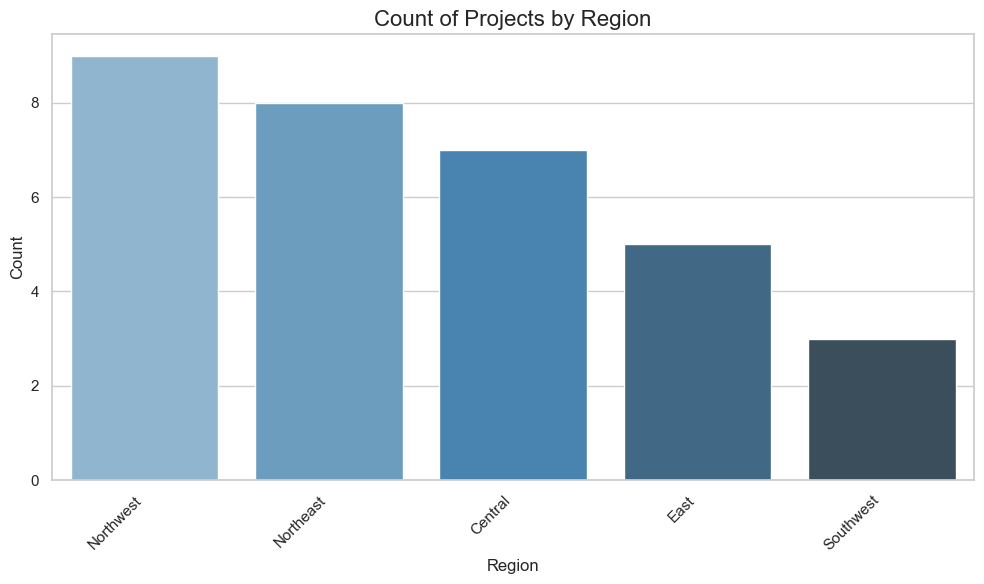

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# Group by the 'Region' column and count the occurrences
region_counts = df['Region'].value_counts()

# Set Seaborn style for the plot
sns.set(style="whitegrid")

# Create a bar chart using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette='Blues_d')

# Set plot title and labels
plt.title('Count of Projects by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent label clipping
plt.tight_layout()

# Show plot
plt.show()


At first glance, it may appear that the **Northeast**, **Central**, and **Northwest** regions of Ontario have the highest number of infrastructure projects. However, a closer examination of the stacked bar chart reveals a more nuanced picture. The **Central region** stands out, not only with the highest total number of projects but also with the **largest proportion** of projects currently under construction. In contrast, the **northern regions** are still predominantly in the **planning phase**, with no significant projects yet in progress.


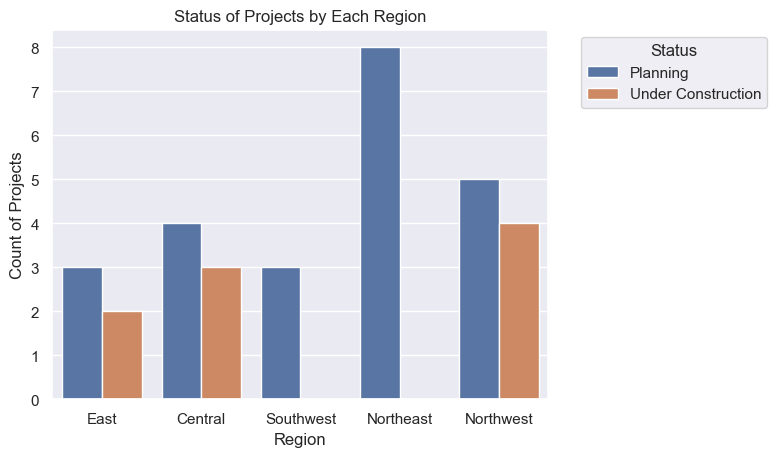

In [11]:

import seaborn as sns
sns.set_theme()
p = sns.countplot(data=df, x='Region', hue='Status', legend=False).set(title ="Status of Projects by Each Region", xlabel="Region", ylabel="Count of Projects")
plt.legend(['Planning', 'Under Construction'], title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show(p)


### 3.2 Project Funding

The **correlation map** below provides a visual representation of the relationship between different funding sources and the status of projects. The correlation values range from **-1 to 1**, with the following interpretations:

- **Values closer to 1**: 
  - Indicates a **positive relationship**, where higher funding is associated with a greater likelihood of project advancement or completion.
  - Suggests that increased funding may effectively boost project progress.
  
- **Values closer to -1**: 
  - Indicates a **negative relationship**, where higher funding may not lead to improved progress. 
  - Could reflect potential delays, inefficiencies, or challenges despite the funding.

This map helps to understand how funding influences project status across different regions and project types.


In [12]:
funding_col = ['Municipal Funding', 'Federal Funding', 'Other Funding', 'Status']
correlation_matrix = df[funding_col].corr()
correlation_matrix = correlation_matrix.round(2)
correlation_matrix



,Municipal Funding,Federal Funding,Other Funding,Status
Municipal Funding,1.00,0.23,-0.55,-0.50
Federal Funding,0.23,1.00,-0.09,-0.41
Other Funding,-0.55,-0.09,1.00,0.28
Status,-0.50,-0.41,0.28,1.00


As shown below, the correlation analysis suggests that funding has **little to no significant effect** on the status of the projects. This indicates that factors beyond funding levels such as **local governance**, **regulatory challenges**, or **logistical issues** may be playing a more prominent role in influencing the progress and completion of these infrastructure initiatives.


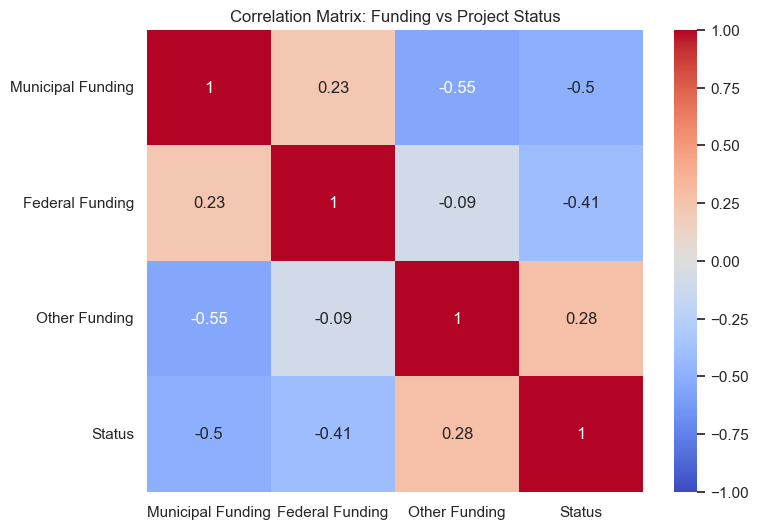

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Correlation Matrix: Funding vs Project Status')
plt.show()

The stacked bar chart below illustrates the **distribution of funding** across Ontario’s different regions. It shows that funding is **evenly distributed** across all regions, with each receiving **fair and comparable support** from various levels of government. This indicates a **balanced allocation of resources** throughout the province, ensuring that no region is disproportionately favored or overlooked.


<Figure size 1000x600 with 0 Axes>

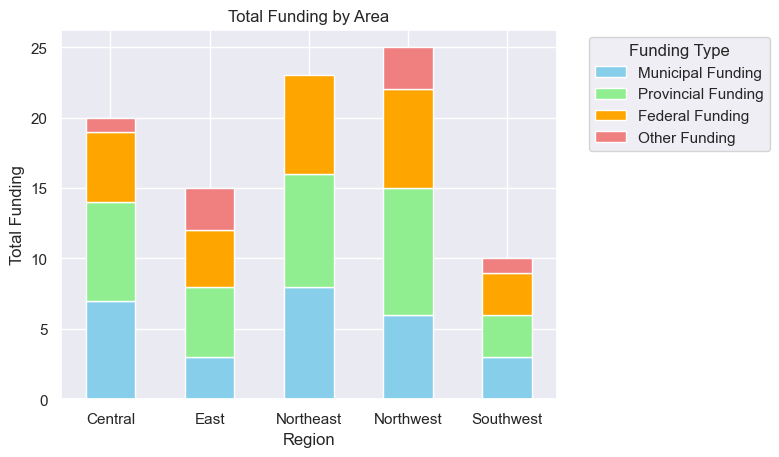

In [14]:

# Group by region and sum up the funding types
funding_by_region = df.groupby('Region')[['Municipal Funding', 'Provincial Funding', 'Federal Funding', 'Other Funding']].sum()

# Plot stacked bar chart
plt.figure(figsize=(10, 6))
funding_by_region.plot(kind='bar', stacked=True, color=['skyblue', 'lightgreen', 'orange', 'lightcoral'])

plt.title('Total Funding by Area')
plt.xlabel('Region')
plt.ylabel('Total Funding')
plt.xticks(rotation=0)  # Rotate x labels for better readability
plt.legend(title="Funding Type", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.show()


The timeline shown in the line plot below indicates that the majority of infrastructure projects are expected to be completed by **2028**, with a development horizon of approximately **four years** for those currently under construction and in the planning phase. This suggests a **rapid pace** of infrastructure development across Ontario, with projects advancing steadily towards completion. As a result, these developments will significantly contribute to the overall growth and modernization of the province.


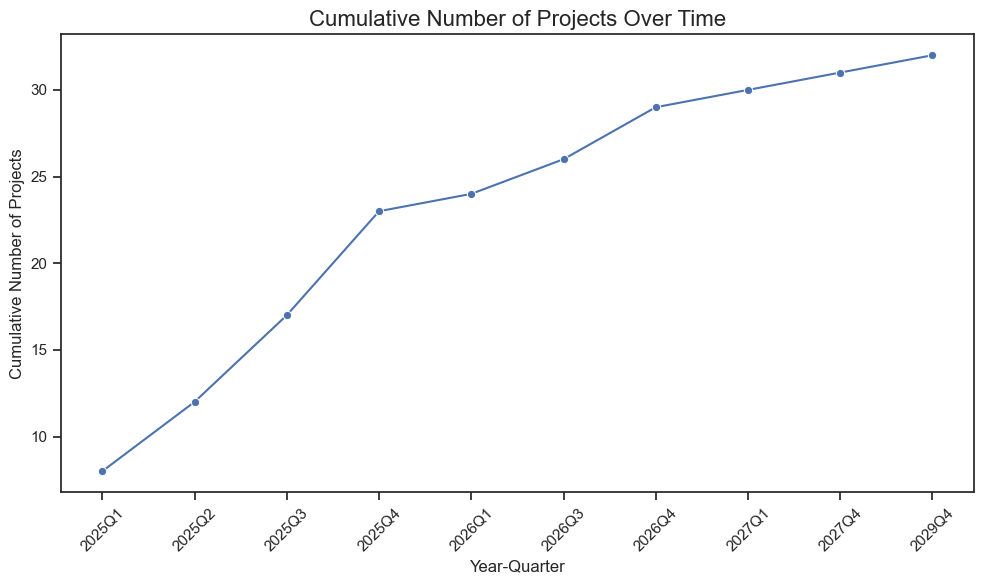

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Target Completion Date' is in datetime format with error handling
df['Target Completion Date'] = pd.to_datetime(df['Target Completion Date'], errors='coerce')

# Extract Year-Quarter from 'Target Completion Date'
df['Year-Quarter'] = df['Target Completion Date'].dt.to_period('Q')

# Group by Year-Quarter and count the number of projects
projects_by_quarter = df.groupby('Year-Quarter')['Project'].count()

# Calculate cumulative sum
cumulative_projects = projects_by_quarter.cumsum()

# Set Seaborn style for the plot
sns.set_style('ticks')


# Create the line plot using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(x=cumulative_projects.index.astype(str), y=cumulative_projects.values, marker='o', color='b')

# Set plot labels and title
plt.title('Cumulative Number of Projects Over Time', fontsize=16)
plt.xlabel('Year-Quarter', fontsize=12)
plt.ylabel('Cumulative Number of Projects', fontsize=12)

# Show plot
plt.xticks(rotation=45)  # Rotate x-ticks for better readability
plt.tight_layout()  # Adjust layout for better spacing
plt.show()


## 4. Discussion

This analysis has provided valuable insights into the ongoing and planned infrastructure projects across Ontario, focusing on regional distribution, funding sources, project status, and timelines. The findings reveal several key trends:

### 4.1 Regional Distribution of Projects
- **Central and Northern Regions**: The central and northern regions of Ontario are receiving the highest concentration of infrastructure investments. 
- **Project Status**: 
  - The **Central region** is leading in terms of projects under construction.
  - The **Northeast** and **Northwest regions** are predominantly in the **planning phase**, suggesting a longer timeline for development in these areas.

### 4.2 Funding Distribution
- **Fair Allocation**: The government funding is distributed fairly across all regions of Ontario, with no noticeable disparity between municipal, provincial, and federal contributions.
- **Impact on Project Status**: Despite equal funding distribution, the correlation analysis reveals that funding does not have a significant direct impact on project progress. This suggests that other factors—such as local governance or logistical challenges—may play a larger role.

### 4.3 Project Timelines
- **Completion by 2028**: The timeline analysis shows that the majority of projects are expected to be completed by **2028**, with a development horizon of approximately four years for those in the **under construction** and **planning** phases.
- **Fast Development**: This indicates that Ontario is experiencing rapid infrastructure development, with projects progressing across all regions at a relatively swift pace.

### 4.4 Implications for Northern Regions
- **Longer Planning Phases**: The northern regions are facing a longer planning phase, which may delay the benefits of infrastructure development for residents in these areas.
- **Policy Focus**: It is important for policymakers to ensure that these regions receive adequate support to transition from planning to construction more efficiently.

### 4.5 Conclusion
- **Overall Growth**: Ontario is on a fast track to improving its infrastructure, benefiting families and communities across the province.
- **Future Considerations**: While the funding distribution appears fair, attention is needed in regions with slower project progress, particularly in the north. Timely execution of projects will be crucial for balanced growth across the province.



## 5. Reference

1. Data Set from [Ontario Public Data](https://data.ontario.ca/dataset/ontario-builds-key-infrastructure-projects/resource/36f92c5b-0c8b-4a4b-b4c5-d15a43894297)
2. Regions retrieved from longitude and latitude using Geopy
3. Visualization including folium from leaflet, seaborn, matplotlib.
4. Data manipulation using pandas
5. OpenAI ChatGPT: "Can you refine these setences".